<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_sa_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S. aureus - Filtering

### By: Mukundan Thanigaivelan

#### July 24, 2026

In this notebook, we filter S. aureus genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

The data have already been log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 645, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 645 (delta 85), reused 32 (delta 32), pack-reused 526 (from 2)
Receiving objects: 100% (645/645), 53.40 MiB | 38.08 MiB/s, done.
Resolving deltas: 100% (335/335), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

## 2. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import re
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. Data filtering

Here we are looking at S. aureus genes in the strain USA300, with expression that has been log transformed and scaled to be between 0 and 1.

### Preparation

In [8]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sapg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [9]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 8961 genes (features) and 3737 samples


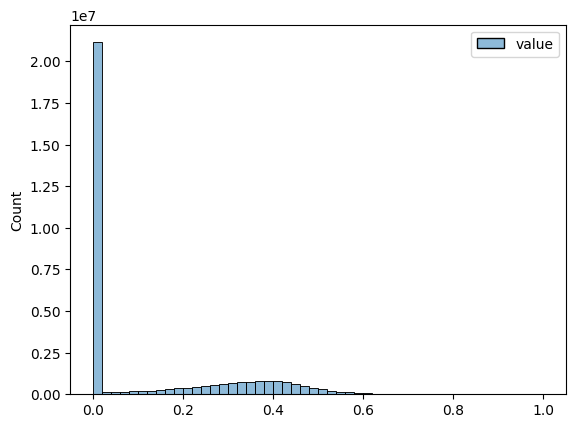

In [10]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

In [11]:
# That's a lot of zeroes.. what percent?
print(f"{int(((all_comp == 0).sum().sum() / all_comp.size) * 100)}% of this compendium is zero.")

63% of this compendium is zero.


### Keep genes in USA300

In [12]:
# Load in gene presence tables
gpa = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_gene_presence_absence.csv', index_col = 0)
gpa.head()

,Non-unique Gene name,Annotation,No. isolates,No. sequences,Avg sequences per isolate,Genome Fragment,Order within Fragment,Accessory Fragment,Accessory Order with Fragment,QC,...,GCF_003052445.1,GCF_008244705.1,GCF_014857975.1,GCF_015475575.1,GCF_016916755.1,GCF_016916765.1,GCF_021284565.1,GCF_022832775.1,GCF_023278065.1,pandb_bacteria_1280
Gene,,,,,,,,,,,,,,,,,,,,,
WP_001294626.1,NaN,PH domain-containing protein,18,18,1,3405,4175,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_880,807c21e70fe3ee94f20b18028164a770_4511,e842c5db9e426c42b31bc4ac5dc193b7_5382,8e9ec6dd6361039c005aea98ba7304d1_4499,e749d233e3a4f981eef508a8913d8c41_5469,615df8abf0557b1242418123747d6b3a_6430,544965d78f6d5c49ee9e7adaf7bd009d_5326,a6d7098b7ef38ff9806fb130a5f01e95_4238,7930e79367e590eb33847b13d273fa6e_4034,pandb_bacteria_1280_01963
WP_001287088.1,NaN,hypothetical protein,18,18,1,3405,4174,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_878,807c21e70fe3ee94f20b18028164a770_4513,e842c5db9e426c42b31bc4ac5dc193b7_5380,8e9ec6dd6361039c005aea98ba7304d1_4501,e749d233e3a4f981eef508a8913d8c41_5467,615df8abf0557b1242418123747d6b3a_6428,544965d78f6d5c49ee9e7adaf7bd009d_5328,a6d7098b7ef38ff9806fb130a5f01e95_4240,7930e79367e590eb33847b13d273fa6e_4036,pandb_bacteria_1280_01964
WP_000379888.1,NaN,L-threonylcarbamoyladenylate synthase,18,18,1,3405,4125,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_791,807c21e70fe3ee94f20b18028164a770_4598,e842c5db9e426c42b31bc4ac5dc193b7_5295,8e9ec6dd6361039c005aea98ba7304d1_4586,e749d233e3a4f981eef508a8913d8c41_5382,615df8abf0557b1242418123747d6b3a_6343,544965d78f6d5c49ee9e7adaf7bd009d_5413,a6d7098b7ef38ff9806fb130a5f01e95_4325,7930e79367e590eb33847b13d273fa6e_4121,pandb_bacteria_1280_02008
WP_000792345.1,NaN,BCCT family transporter,18,18,1,3405,4307,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_1371,807c21e70fe3ee94f20b18028164a770_4771,e842c5db9e426c42b31bc4ac5dc193b7_2561,8e9ec6dd6361039c005aea98ba7304d1_4759,e749d233e3a4f981eef508a8913d8c41_2968,615df8abf0557b1242418123747d6b3a_3083,544965d78f6d5c49ee9e7adaf7bd009d_2551,a6d7098b7ef38ff9806fb130a5f01e95_4488,7930e79367e590eb33847b13d273fa6e_4294,pandb_bacteria_1280_02083
modA,NaN,molybdate ABC transporter substrate-binding pr...,18,18,1,3405,689,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_1707,807c21e70fe3ee94f20b18028164a770_4965,e842c5db9e426c42b31bc4ac5dc193b7_2757,8e9ec6dd6361039c005aea98ba7304d1_4951,e749d233e3a4f981eef508a8913d8c41_3162,615df8abf0557b1242418123747d6b3a_1096,544965d78f6d5c49ee9e7adaf7bd009d_2745,a6d7098b7ef38ff9806fb130a5f01e95_4686,7930e79367e590eb33847b13d273fa6e_4488,pandb_bacteria_1280_02167


In [15]:
# Get only gene names in strain columns
gpa_strains = gpa[
  ['GCF_000009645.1', 'GCF_000010465.1', 'GCF_000012045.1',
   'GCF_000013425.1', 'GCF_000756205.1', 'GCF_001456215.1',
   'GCF_001900185.1', 'GCF_002993865.1', 'GCF_003052445.1',
   'GCF_008244705.1', 'GCF_014857975.1', 'GCF_015475575.1',
   'GCF_016916755.1', 'GCF_016916765.1', 'GCF_021284565.1',
   'GCF_022832775.1', 'GCF_023278065.1', 'pandb_bacteria_1280'
  ]
]
gpa_strains.shape

(9935, 18)

In [16]:
# Concatenate all gene names into one string, filling in missing values with ''
gpa_strains['names_cat'] = gpa_strains.fillna('').agg(' '.join, axis=1)
gpa_strains['names_cat'].head()

Gene
WP_001294626.1    12b493b74dec297122c11824ed05ba01_4285 dd621b95...
WP_001287088.1    12b493b74dec297122c11824ed05ba01_4287 dd621b95...
WP_000379888.1    12b493b74dec297122c11824ed05ba01_4376 dd621b95...
WP_000792345.1    12b493b74dec297122c11824ed05ba01_4553 dd621b95...
modA              12b493b74dec297122c11824ed05ba01_4751 dd621b95...
Name: names_cat, dtype: str

In [17]:
# Add first_name_comp column
gpa_strains['first_name_comp'] = gpa_strains['names_cat'].str.split().apply(lambda x: x[0])
gpa_strains.head()

,GCF_000009645.1,GCF_000010465.1,GCF_000012045.1,GCF_000013425.1,GCF_000756205.1,GCF_001456215.1,GCF_001900185.1,GCF_002993865.1,GCF_003052445.1,GCF_008244705.1,GCF_014857975.1,GCF_015475575.1,GCF_016916755.1,GCF_016916765.1,GCF_021284565.1,GCF_022832775.1,GCF_023278065.1,pandb_bacteria_1280,names_cat,first_name_comp
Gene,,,,,,,,,,,,,,,,,,,,
WP_001294626.1,12b493b74dec297122c11824ed05ba01_4285,dd621b957428e8bac9d4e4836fc25ff0_4589,86be33626174370752bad760edea7ad6_4305,cds-YP_500787.1,9185d483bdb4535fed11f5978edaa119_4257,9ab1425e5eb2f9df6f6be6d193592bac_4100,53e0e900c609974f696d0a3fe29fcfc8_4424,7de8e2764d7131e46dce93449e724093_4475,48bdb69ddbf0f0ac20d6a159eb106076_880,807c21e70fe3ee94f20b18028164a770_4511,e842c5db9e426c42b31bc4ac5dc193b7_5382,8e9ec6dd6361039c005aea98ba7304d1_4499,e749d233e3a4f981eef508a8913d8c41_5469,615df8abf0557b1242418123747d6b3a_6430,544965d78f6d5c49ee9e7adaf7bd009d_5326,a6d7098b7ef38ff9806fb130a5f01e95_4238,7930e79367e590eb33847b13d273fa6e_4034,pandb_bacteria_1280_01963,12b493b74dec297122c11824ed05ba01_4285 dd621b95...,12b493b74dec297122c11824ed05ba01_4285
WP_001287088.1,12b493b74dec297122c11824ed05ba01_4287,dd621b957428e8bac9d4e4836fc25ff0_4591,86be33626174370752bad760edea7ad6_4307,cds-YP_500788.1,9185d483bdb4535fed11f5978edaa119_4259,9ab1425e5eb2f9df6f6be6d193592bac_4102,53e0e900c609974f696d0a3fe29fcfc8_4426,7de8e2764d7131e46dce93449e724093_4477,48bdb69ddbf0f0ac20d6a159eb106076_878,807c21e70fe3ee94f20b18028164a770_4513,e842c5db9e426c42b31bc4ac5dc193b7_5380,8e9ec6dd6361039c005aea98ba7304d1_4501,e749d233e3a4f981eef508a8913d8c41_5467,615df8abf0557b1242418123747d6b3a_6428,544965d78f6d5c49ee9e7adaf7bd009d_5328,a6d7098b7ef38ff9806fb130a5f01e95_4240,7930e79367e590eb33847b13d273fa6e_4036,pandb_bacteria_1280_01964,12b493b74dec297122c11824ed05ba01_4287 dd621b95...,12b493b74dec297122c11824ed05ba01_4287
WP_000379888.1,12b493b74dec297122c11824ed05ba01_4376,dd621b957428e8bac9d4e4836fc25ff0_4676,86be33626174370752bad760edea7ad6_4392,cds-YP_500833.1,9185d483bdb4535fed11f5978edaa119_4344,9ab1425e5eb2f9df6f6be6d193592bac_4191,53e0e900c609974f696d0a3fe29fcfc8_4511,7de8e2764d7131e46dce93449e724093_4562,48bdb69ddbf0f0ac20d6a159eb106076_791,807c21e70fe3ee94f20b18028164a770_4598,e842c5db9e426c42b31bc4ac5dc193b7_5295,8e9ec6dd6361039c005aea98ba7304d1_4586,e749d233e3a4f981eef508a8913d8c41_5382,615df8abf0557b1242418123747d6b3a_6343,544965d78f6d5c49ee9e7adaf7bd009d_5413,a6d7098b7ef38ff9806fb130a5f01e95_4325,7930e79367e590eb33847b13d273fa6e_4121,pandb_bacteria_1280_02008,12b493b74dec297122c11824ed05ba01_4376 dd621b95...,12b493b74dec297122c11824ed05ba01_4376
WP_000792345.1,12b493b74dec297122c11824ed05ba01_4553,dd621b957428e8bac9d4e4836fc25ff0_4849,86be33626174370752bad760edea7ad6_4565,cds-YP_500912.1,9185d483bdb4535fed11f5978edaa119_4509,9ab1425e5eb2f9df6f6be6d193592bac_4358,53e0e900c609974f696d0a3fe29fcfc8_4687,7de8e2764d7131e46dce93449e724093_4737,48bdb69ddbf0f0ac20d6a159eb106076_1371,807c21e70fe3ee94f20b18028164a770_4771,e842c5db9e426c42b31bc4ac5dc193b7_2561,8e9ec6dd6361039c005aea98ba7304d1_4759,e749d233e3a4f981eef508a8913d8c41_2968,615df8abf0557b1242418123747d6b3a_3083,544965d78f6d5c49ee9e7adaf7bd009d_2551,a6d7098b7ef38ff9806fb130a5f01e95_4488,7930e79367e590eb33847b13d273fa6e_4294,pandb_bacteria_1280_02083,12b493b74dec297122c11824ed05ba01_4553 dd621b95...,12b493b74dec297122c11824ed05ba01_4553
modA,12b493b74dec297122c11824ed05ba01_4751,dd621b957428e8bac9d4e4836fc25ff0_5043,86be33626174370752bad760edea7ad6_4759,cds-YP_501011.1,9185d483bdb4535fed11f5978edaa119_4699,9ab1425e5eb2f9df6f6be6d193592bac_4540,53e0e900c609974f696d0a3fe29fcfc8_4881,7de8e2764d7131e46dce93449e724093_4931,48bdb69ddbf0f0ac20d6a159eb106076_1707,807c21e70fe3ee94f20b18028164a770_4965,e842c5db9e426c42b31bc4ac5dc193b7_2757,8e9ec6dd6361039c005aea98ba7304d1_4951,e749d233e3a4f981eef508a8913d8c41_3162,615df8abf0557b1242418123747d6b3a_1096,544965d78f6d5c49ee9e7adaf7bd009d_2745,a6d7098b7ef38ff9806fb130a5f01e95_4686,7930e79367e590eb33847b13d273fa6e_4488,pandb_bacteria_128

In [30]:
# Get all the genes in the USA300 strain
usa300_genes = gpa_strains['first_name_comp'].loc[gpa_strains['GCF_002993865.1'].notna()]

# Keep only USA300 genes in the compendium
usa300_genes = usa300_genes[usa300_genes.isin(all_comp.index)]

len(usa300_genes)

2765

In [33]:
# Get the compendium for these genes
usa300_comp = all_comp.loc[usa300_genes]
usa300_comp.shape

(2765, 3737)

<Axes: ylabel='Count'>

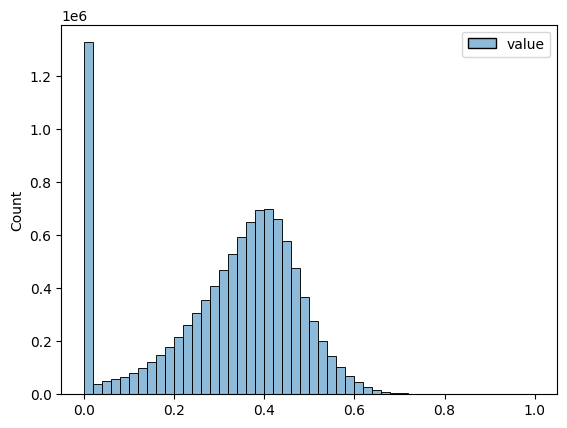

In [34]:
sns.histplot(pd.melt(usa300_comp), bins = 50)

### Gene-wise Filtering

In [35]:
# Get gene sample statistics
gene_stats = usa300_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
12b493b74dec297122c11824ed05ba01_4285,3737.0,0.420200,0.031521,0.279471,0.401637,0.417375,0.434090,0.611945
12b493b74dec297122c11824ed05ba01_4287,3737.0,0.316662,0.048477,0.000000,0.292055,0.317079,0.341392,0.517495
12b493b74dec297122c11824ed05ba01_4376,3737.0,0.378529,0.034187,0.187586,0.362492,0.381951,0.398913,0.581566
12b493b74dec297122c11824ed05ba01_4553,3737.0,0.380890,0.102447,0.000000,0.323830,0.393616,0.455001,0.607063
12b493b74dec297122c11824ed05ba01_4751,3737.0,0.410952,0.041978,0.238699,0.386147,0.411318,0.435825,0.612903


Text(0.5, 1.0, 'Mean vs. median expression')

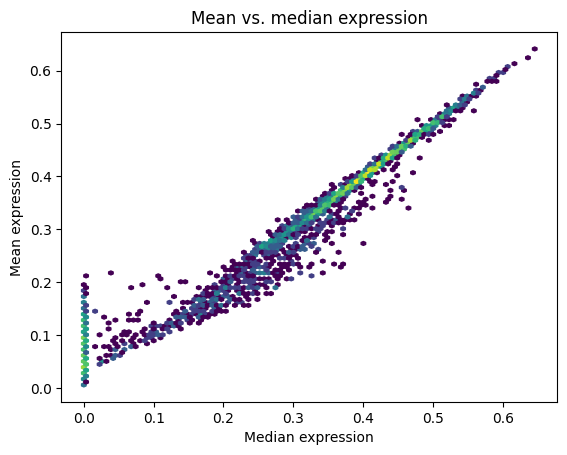

In [37]:
# Preliminary hexagonal binning log-scaled plot of 75th percentile versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log'
)

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

In [45]:
# Empirically determined constant for threshold
c1, c2 = 0.03, -0.03

# Cutoff lines to filter genes
x1 = np.linspace(0, 0.7, 200)
x2 = np.linspace(0, 0.7, 200)

y1 = x1 + c1
y2 = x2 + c2

Text(0.5, 1.0, 'Mean vs. median expression')

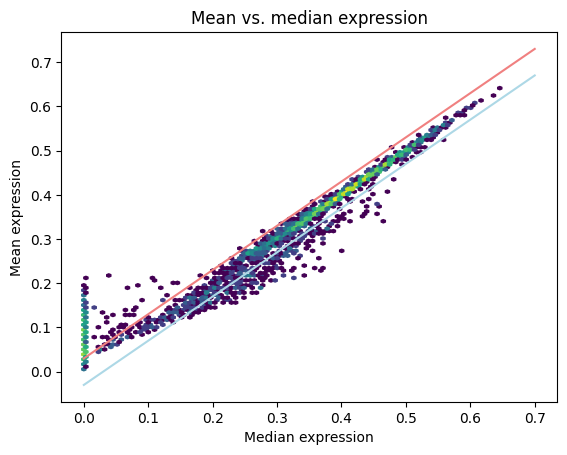

In [46]:
# Plot with threshold lines for filtering out genes
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log'
)

plt.plot(x1, y1, color = 'lightcoral')
plt.plot(x2, y2, color = 'lightblue')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

In [48]:
# Set thresholds to remove genes
threshold1 = gene_stats['50%'] + c1 # red
threshold2 = gene_stats['50%'] + c2 # blue

# Genes to remove
genes_to_rm = gene_stats[
  (gene_stats['mean'] > threshold1) |
  (gene_stats['mean'] < threshold2)
]
genes_to_rm.shape

(591, 8)

In [50]:
# Remove the genes
filtered_genes = usa300_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(2174, 3737)

In [51]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. median expression')

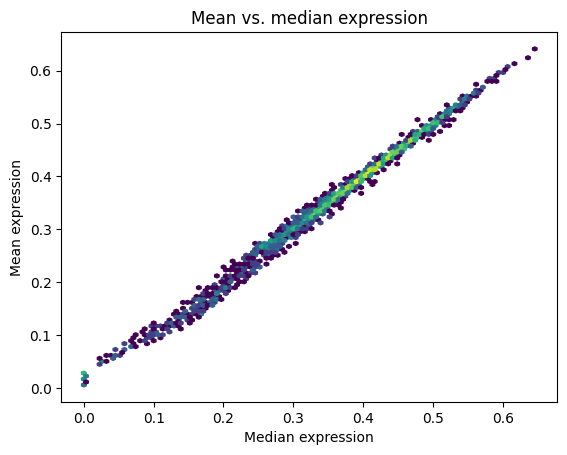

In [52]:
# Plot of gene expression 75th percentile versus mean after filtering
plt.hexbin(
  x = filtered_stats['50%'],
  y = filtered_stats['mean'],
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

<Axes: ylabel='Count'>

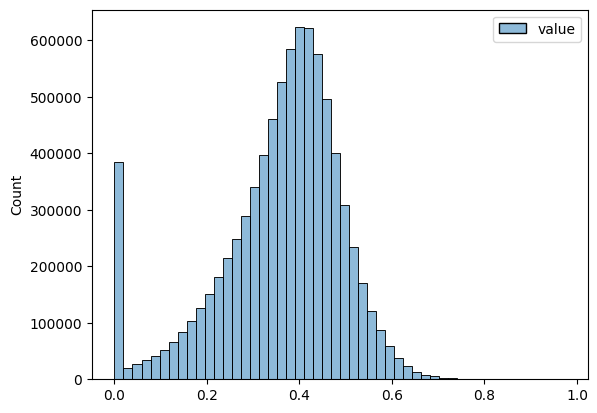

In [53]:
# Histogram of gene expression - getting better but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)

### Experiment-wise Filtering

In [54]:
# Get experiment sample statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
DRX011556,2174.0,0.358111,0.125289,0.0,0.293496,0.371170,0.434961,0.707659
DRX011557,2174.0,0.362853,0.123714,0.0,0.301695,0.375017,0.439086,0.784771
DRX011558,2174.0,0.361467,0.127111,0.0,0.302542,0.373261,0.439413,0.716095
DRX011559,2174.0,0.363593,0.128588,0.0,0.302885,0.381288,0.447463,0.694309
DRX011560,2174.0,0.354082,0.142570,0.0,0.299739,0.379094,0.445717,0.687590


Text(0.5, 1.0, 'Mean vs. median expression')

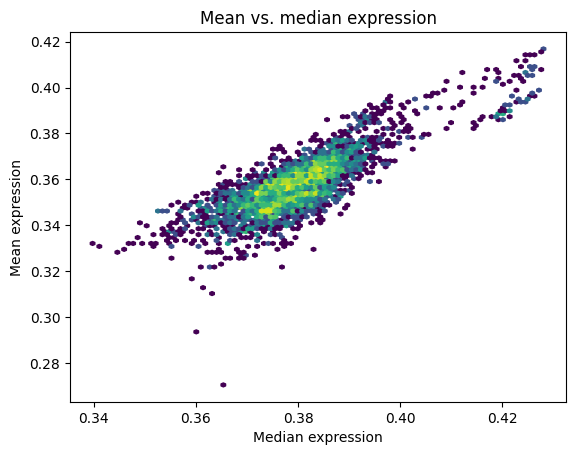

In [55]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log'
)

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

In [266]:
# Empirically determined constant for threshold
c = -0.013

# Cutoff lines to filter samples
x = np.linspace(0.32, 0.42, 200)
y = x + c

Text(0.5, 1.0, 'Mean vs. median expression')

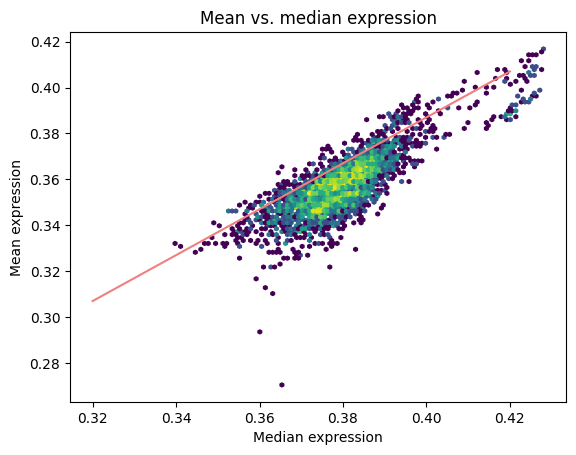

In [267]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log'
)

plt.plot(x, y, color = 'lightcoral')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

In [268]:
# Set thresholds to remove samples
threshold1 = exp_stats['50%'] + c

# Samples to remove
exps_to_rm = exp_stats[exp_stats['mean'] < threshold1]
exps_to_rm.shape

(3378, 8)

In [269]:
# Remove the samples
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(2174, 359)

In [270]:
# Get filtered stats
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Mean vs. median expression')

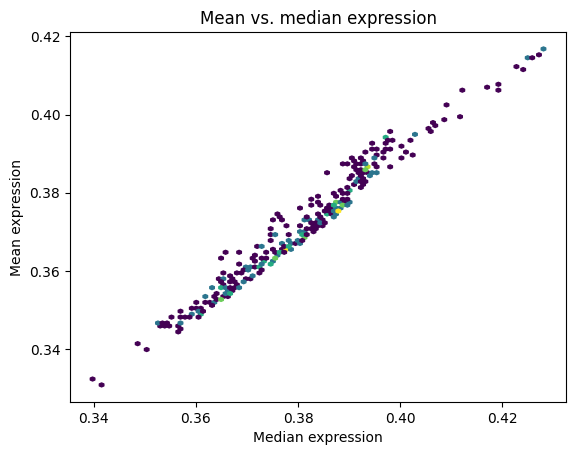

In [271]:
# Plot of sample expression median versus mean after filtering
plt.hexbin(
  x = final_stats['50%'],
  y = final_stats['mean'],
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

<Axes: ylabel='Count'>

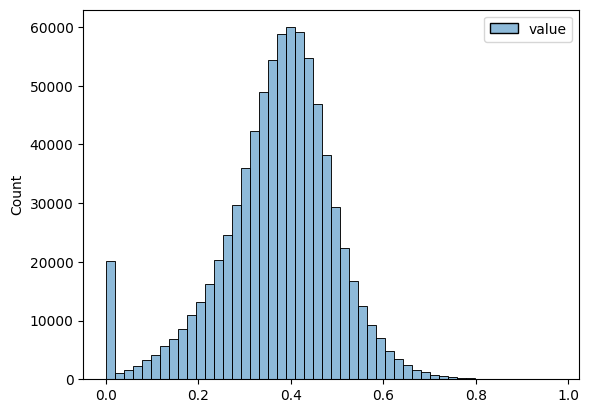

In [272]:
# Histogram of gene expression - somewhat good!
sns.histplot(pd.melt(filtered_df), bins=50)

In [273]:
print(
  f"There are {round(((filtered_df == 0).sum().sum() / filtered_df.size) * 100, 2)}% zeroes in the compendium."
)

There are 2.53% zeroes in the compendium.


### Final Filtered Data

In [274]:
# Size of filtered genes and samples
filtered_df.shape

(2174, 359)

## 4. Data post-processing and saving

We pull the raw counts for these filtered data and then normalize again through:

- Ratio of Medians
- Log-transform
- 0-1 scaling

Then, we save the data to a CSV.

In [275]:
raw_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/num_reads_saur_pan_genome_saur_comp_k15.csv',
  index_col = 0
)
raw_df.shape

(8961, 4234)

In [280]:
# Pull our filtered data in raw counts
raw_filt = raw_df.loc[filtered_df.index, filtered_df.columns]
raw_filt.head()

,DRX011557,DRX011558,DRX367187,DRX367188,DRX367686,DRX367688,DRX367689,DRX367690,ERX1409572,ERX1409575,...,SRX18051348,SRX19599084,SRX20362041,SRX20630197,SRX20630202,SRX21064889,SRX21767162,SRX21908249,SRX21908250,SRX23216296
12b493b74dec297122c11824ed05ba01_4285,253.000,175.00,212.000,83.000,39.464,61.876,46.745,30.000,5400.000,4168.000,...,6120.000,605.0,2570.000,7847.000,10997.000,743.0,650.00,160.0,153.0,3010.00
12b493b74dec297122c11824ed05ba01_4287,18.000,27.00,46.000,17.000,16.537,32.924,18.293,20.953,906.000,804.000,...,964.000,11.0,404.000,1575.000,1767.000,102.0,99.00,61.0,51.0,824.00
12b493b74dec297122c11824ed05ba01_4376,214.000,179.00,251.000,97.000,10.061,23.003,25.800,19.000,6229.000,3951.000,...,7813.000,64.0,126.000,2661.000,2889.000,201.0,94.00,150.0,122.0,1405.00
12b493b74dec297122c11824ed05ba01_4553,14.858,78.12,56.705,43.512,1.698,2.030,1.995,3.671,4280.038,11361.795,...,575.069,8580.0,18348.734,21200.601,9683.947,1549.6,141.06,1645.0,3588.0,2598.21
12b493b74dec297122c11824ed05ba01_4751,68.000,126.00,181.000,137.000,107.844,62.545,52.712,65.369,4488.000,4832.000,...,5592.000,210.0,864.000,3487.000,4038.000,1503.0,978.00,441.0,438.0,3552.00


In [281]:
# Ratio of Medians Scaling
norm_counts, size_factors = deseq2_norm(raw_filt.T)
norm_counts = norm_counts.T
norm_counts.head()

,DRX011557,DRX011558,DRX367187,DRX367188,DRX367686,DRX367688,DRX367689,DRX367690,ERX1409572,ERX1409575,...,SRX18051348,SRX19599084,SRX20362041,SRX20630197,SRX20630202,SRX21064889,SRX21767162,SRX21908249,SRX21908250,SRX23216296
12b493b74dec297122c11824ed05ba01_4285,1687.455915,1175.826952,1442.881908,1075.807605,748.061653,1158.041214,1014.238383,975.305793,1045.269600,1022.616126,...,1037.380277,1435.174078,1718.555528,1864.999062,2861.531585,1148.417272,920.654532,399.855549,320.515459,1046.605957
12b493b74dec297122c11824ed05ba01_4287,120.056152,181.413301,313.078150,220.346136,313.467858,616.189620,396.907963,681.186076,175.373011,197.260884,...,163.404344,26.094074,270.154254,374.330766,459.791426,157.656207,140.222767,152.444928,106.838486,286.512727
12b493b74dec297122c11824ed05ba01_4376,1427.334253,1202.702997,1708.317731,1257.269128,190.711745,430.512994,559.789289,617.693669,1205.737840,969.375315,...,1324.354919,151.820068,84.256030,632.440742,751.747272,310.675467,133.140809,374.864577,255.574418,488.532017
12b493b74dec297122c11824ed05ba01_4553,99.099684,524.889152,385.936880,563.982416,32.186517,37.992496,43.286032,119.344919,828.480297,2787.609115,...,97.477980,20353.377835,12269.773637,5038.753788,2519.861799,2395.137827,199.796197,4111.014858,7516.401737,903.422613
12b493b74dec297122c11824ed05ba01_4751,453.545463,846.595406,1231.894459,1775.730624,2044.241864,1170.561894,1143.705929,2125.158813,868.735178,1185.528100,...,947.880802,498.159597,577.755633,828.756433,1050.728793,2323.110579,1385.230973,1102.101856,917.554058,1235.064571


In [282]:
# Log2 scaling
log_norm_counts = np.log2(norm_counts + 1)
log_norm_counts.head()

,DRX011557,DRX011558,DRX367187,DRX367188,DRX367686,DRX367688,DRX367689,DRX367690,ERX1409572,ERX1409575,...,SRX18051348,SRX19599084,SRX20362041,SRX20630197,SRX20630202,SRX21064889,SRX21767162,SRX21908249,SRX21908250,SRX23216296
12b493b74dec297122c11824ed05ba01_4285,10.721489,10.200686,10.495737,10.072545,9.548941,10.178716,9.987603,9.931189,10.031039,9.999459,...,10.020119,10.488015,10.747820,10.865733,11.483076,10.166687,9.848082,8.646939,8.328744,10.032880
12b493b74dec297122c11824ed05ba01_4287,6.919533,7.511067,8.294980,7.790160,8.296769,9.269570,8.636291,9.414021,7.462486,7.631256,...,7.361105,4.759905,8.082970,8.552019,8.847970,7.309760,7.141829,7.261577,6.752728,8.167482
12b493b74dec297122c11824ed05ba01_4376,10.480118,10.233264,10.739205,10.297225,7.582795,8.753260,9.131315,9.273081,10.236897,9.922399,...,10.372163,7.255690,6.413730,9.307066,9.556022,8.283901,7.067604,8.554069,8.003234,8.935259
12b493b74dec297122c11824ed05ba01_4553,6.645294,9.038615,8.595954,9.142062,5.052525,5.285125,5.468780,6.911031,9.696064,11.445330,...,6.621729,14.313052,13.582939,12.299138,11.299701,11.226495,7.649588,12.005630,12.876018,9.820853
12b493b74dec297122c11824ed05ba01_4751,8.828281,9.727232,10.267834,10.795009,10.998056,10.194217,10.160761,11.054034,9.764432,10.212531,...,9.890083,8.963357,9.176811,9.696544,10.038547,11.182463,10.436952,10.107350,9.843221,10.271538


In [283]:
# 0-1 scaling
log_01_norm_counts = (log_norm_counts - log_norm_counts.min()) / (log_norm_counts.max() - log_norm_counts.min())
log_01_norm_counts.head()

,DRX011557,DRX011558,DRX367187,DRX367188,DRX367686,DRX367688,DRX367689,DRX367690,ERX1409572,ERX1409575,...,SRX18051348,SRX19599084,SRX20362041,SRX20630197,SRX20630202,SRX21064889,SRX21767162,SRX21908249,SRX21908250,SRX23216296
12b493b74dec297122c11824ed05ba01_4285,0.549016,0.573331,0.633447,0.544391,0.591199,0.575744,0.580908,0.572695,0.587669,0.603535,...,0.548998,0.549177,0.568919,0.628194,0.621475,0.558032,0.487793,0.439362,0.430763,0.532564
12b493b74dec297122c11824ed05ba01_4287,0.354329,0.422161,0.500625,0.421035,0.513673,0.524320,0.502312,0.542872,0.437190,0.460598,...,0.403312,0.249240,0.427859,0.494428,0.478861,0.401220,0.353747,0.368970,0.349252,0.433545
12b493b74dec297122c11824ed05ba01_4376,0.536656,0.575162,0.648141,0.556534,0.469470,0.495115,0.531104,0.534745,0.599729,0.598884,...,0.568287,0.379925,0.339501,0.538081,0.517181,0.454689,0.350071,0.434643,0.413928,0.474301
12b493b74dec297122c11824ed05ba01_4553,0.340286,0.508017,0.518790,0.494101,0.312814,0.298945,0.318080,0.398534,0.568044,0.690803,...,0.362802,0.749465,0.718991,0.711065,0.611551,0.616203,0.378898,0.610021,0.665949,0.521310
12b493b74dec297122c11824ed05ba01_4751,0.452071,0.546720,0.619692,0.583438,0.680917,0.576621,0.590979,0.637446,0.572050,0.616395,...,0.541874,0.469342,0.485760,0.560598,0.543296,0.613786,0.516961,0.513567,0.509092,0.545233


In [284]:
# Save to a CSV file
log_01_norm_counts.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_usa300_lcn01_medmean_normal_muk.csv',
  index = True
)

In [285]:
# Verify that I can load the CSV back in here
filtered_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_usa300_lcn01_medmean_normal_muk.csv',
  index_col = 0
)
filtered_df.shape

(2174, 359)

<Axes: ylabel='Count'>

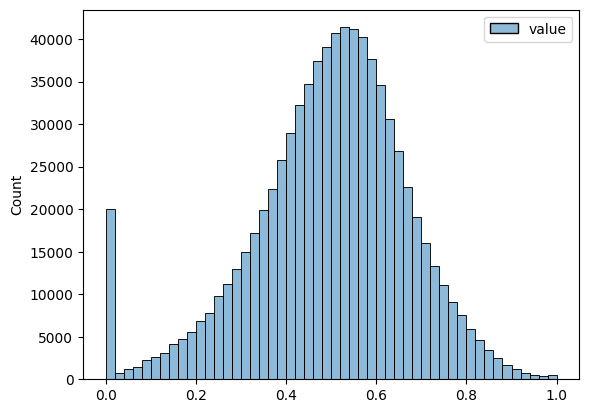

In [287]:
# Final data distribution
sns.histplot(pd.melt(filtered_df), bins = 50)